## Кейс 1
### Состав команды: Чмутенко Елена

### Бинарная классификация с использованием набора данных об оттоке банковских средств (Предсказание оттока клиентов банка)

#### [Ссылка на Kaggle](https://www.kaggle.com/competitions/playground-series-s4e1/data)

## 1. Предобработка данных

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
from phik.report import plot_correlation_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
RANDOM_STATE = 42
%matplotlib inline

In [4]:
df = pd.read_csv('../../data/train.csv', index_col=0)

df.head(3)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.0,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.0,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.0,2,1.0,0.0,184866.69,0


### 1.1 Пропуски

In [5]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### 1.2 Наличие полных дублей

In [6]:
print(f"Количество дубликатов: {df.duplicated().sum()}")
df = df.drop_duplicates()

Количество дубликатов: 0


### 1.3 Удаление неинформативных признаков

In [7]:
df = df.drop(columns=['CustomerId', 'Surname'])

### 1.4 Конвертация типов данных датасета в более компактные

In [8]:
def apply_conversions(data: pd.DataFrame) -> pd.DataFrame:
    """ Конвертирует категориальные колонки в тип `category` для экономии памяти и ускорения вычислений.
    Числовые колонки с малыми значениями конвертирует в более компактные типы.
    
    """
    df = data.copy()
    
    categ_cols = df.select_dtypes(include='object').columns
    df[categ_cols] = df[categ_cols].astype('category')
    
    micro_cols = ['HasCrCard', 'IsActiveMember', 'Tenure', 'NumOfProducts', 'Age', 'Exited']
    df[micro_cols] = df[micro_cols].astype('int8')
    df['CreditScore'] = df['CreditScore'].astype('int16')    
    return df
    

### 1.5 Сохранение результатов предобработки

In [9]:
df = apply_conversions(df)
df.info()
df.to_csv('../../data/preprocessed.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 165034 entries, 0 to 165033
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   CreditScore      165034 non-null  int16   
 1   Geography        165034 non-null  category
 2   Gender           165034 non-null  category
 3   Age              165034 non-null  int8    
 4   Tenure           165034 non-null  int8    
 5   Balance          165034 non-null  float64 
 6   NumOfProducts    165034 non-null  int8    
 7   HasCrCard        165034 non-null  int8    
 8   IsActiveMember   165034 non-null  int8    
 9   EstimatedSalary  165034 non-null  float64 
 10  Exited           165034 non-null  int8    
dtypes: category(2), float64(2), int16(1), int8(6)
memory usage: 5.4 MB


In [10]:
print("Категориальные колонки (описательные статистики)")
print(df.describe(include='category'))
print()
print("Числовые колонки (описательные статистики)")
df.describe()

Категориальные колонки (описательные статистики)
       Geography  Gender
count     165034  165034
unique         3       2
top       France    Male
freq       94215   93150

Числовые колонки (описательные статистики)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,656.454373,38.125883,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,8.867207,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [11]:
X = df.drop(columns=['Exited'])
y = df['Exited']

## 2. Разведочный анализ данных

In [12]:
profile_report = ProfileReport(X, title="Profiling Report", 
                               correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "kendall": {"calculate": False},   
        "cramers": {"calculate": True},
        "phi_k": {"calculate": True}
    })
#profile_report

### 2.1 Корреляции между признаками (без учета целевой переменной)

interval columns not set, guessing: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


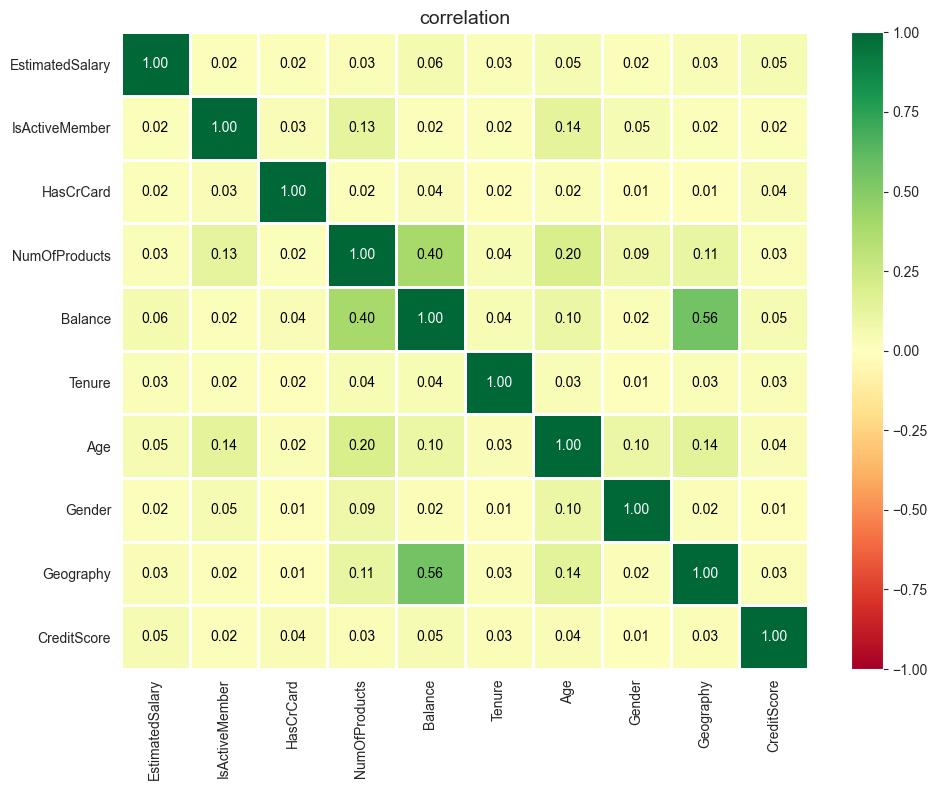

In [13]:
corr_matrix = X.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

#### Вывод:
- 165034 объектов, 10 признаков 
- пропусков в данных нет
- полные дубли удалены
- сильные корреляции между признаками отсутствуют, но есть умереннная между признаками `Balance` - `Geography`(0.56) и `Balance` - `NumOfProducts` (0.40)
- Числовые признаки: `CreditScore`, `Age`, `Tenure`, `EstimatedSalary`, `Balance`
- Категориальные признаки: `IsActiveMember`, `HasCrCard`, `Gender`, `NumOfProducts`, `Geography`
 

### 2.2 Анализ категориальных признаков

In [21]:
cat_cols = ['IsActiveMember', 'HasCrCard', 'Gender', 'NumOfProducts', 'Geography']
for col in cat_cols:
    print(X[col].value_counts())
    print()

IsActiveMember
0    82885
1    82149
Name: count, dtype: int64

HasCrCard
1    124428
0     40606
Name: count, dtype: int64

Gender
Male      93150
Female    71884
Name: count, dtype: int64

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64



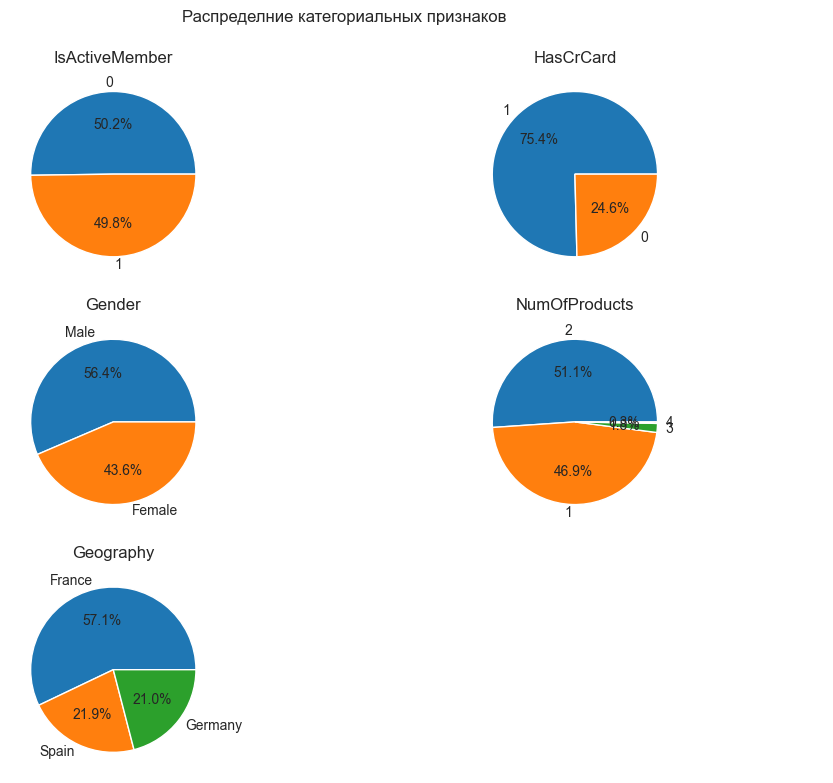

In [15]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
fig.suptitle("Распределние категориальных признаков")

for ax, col in zip(axes.ravel(), cat_cols):
    counts = X[col].value_counts()
    ax.pie(counts, 
           labels=counts.index,
           autopct='%1.1f%%')
    ax.set_title(col)
    
axes[2][1].axis('off') # Скрываем пустой шестой график
plt.tight_layout(pad=1.5)
plt.show()

IsActiveMember
0    29.71%
1    12.53%
Name: Exited, dtype: object


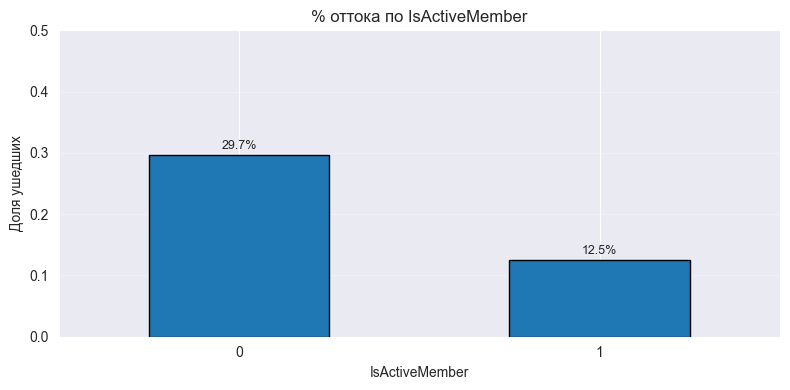

HasCrCard
0    22.74%
1    20.64%
Name: Exited, dtype: object


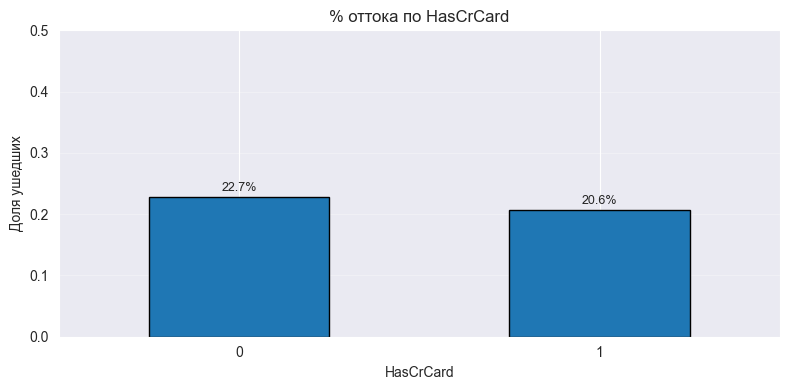

Gender
Female    27.97%
Male      15.91%
Name: Exited, dtype: object


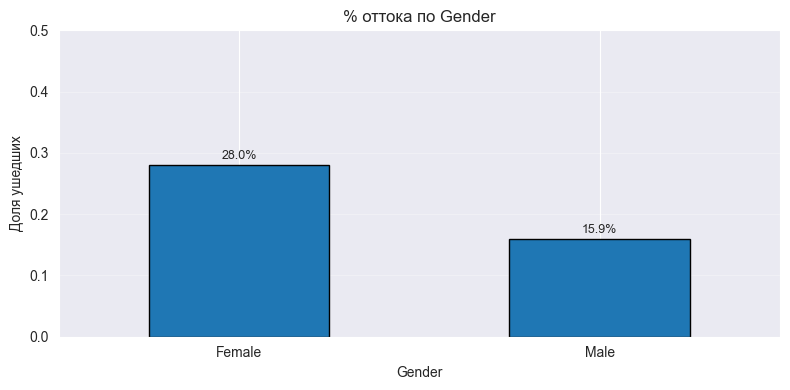

NumOfProducts
1    34.71%
2     6.04%
3    88.25%
4    87.58%
Name: Exited, dtype: object


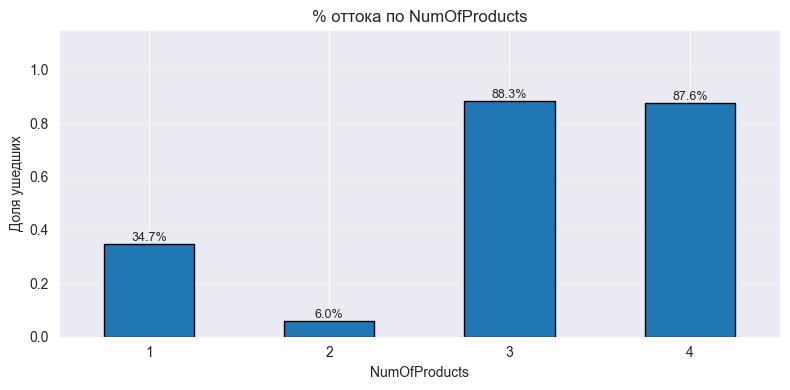

Geography
France     16.53%
Germany     37.9%
Spain      17.22%
Name: Exited, dtype: object


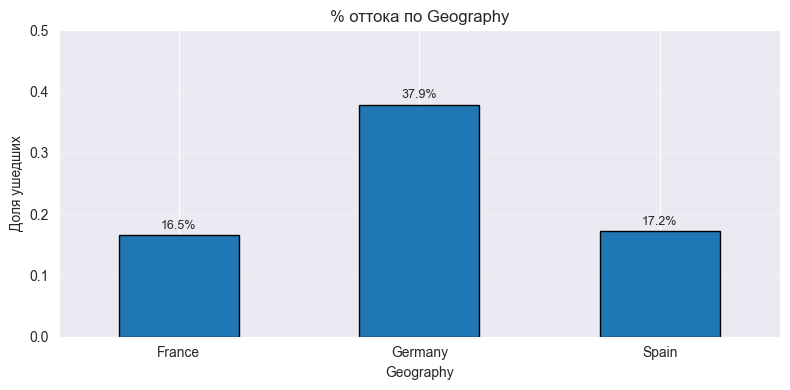

In [16]:
for feature in cat_cols:
    # Считаем % оттока по категориям
    churn_rate = df.groupby(feature, observed=True)['Exited'].mean()
    
    print((churn_rate * 100).round(2).astype(str) + '%')
    
    plt.figure(figsize=(8, 4))
    churn_rate.plot(kind='bar', edgecolor='black')
    
    # Добавляем проценты на столбцы
    for i, v in enumerate(churn_rate.values):
        plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=9)
    
    plt.title(f'% оттока по {feature}')
    plt.xlabel(feature)
    plt.ylabel('Доля ушедших')
    plt.ylim(0, max(churn_rate.max() * 1.3, 0.5))
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Вывод: 
* Бинарный признак `IsActiveMember` -  активность сильно снижает отток, оставим признак в исходном виде
* `HasCrCard` - дисбаланс признака 3 : 1 и разница во влиянии на таргет 2 п.п. В дальнейшем ри отборе признаков попробуем удалить признак
* `Gender` признак c 2 значениями. Применим к признаку One-Hot Encoding
* `NumOfProducts` категории 3 и 4 встречаются крайне редко (менее 1%), их можно попробовать объединить в 1 группу `3+`
* `Geography` клиенты из Германии уходят более чем 2 раза чаще, их доля в выборке не самая большая (21%). Применим к признаку One-Hot Encoding

### 2.3 Баланс классов

In [17]:
print(df['Exited'].value_counts())

Exited
0    130113
1     34921
Name: count, dtype: int64


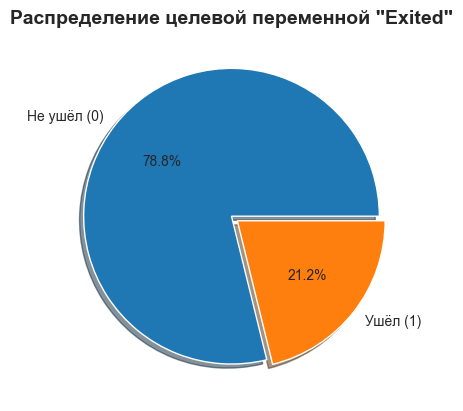

In [18]:
counts = df['Exited'].value_counts()
plt.pie(counts, 
        labels=[f'Не ушёл ({counts.index[0]})', f'Ушёл ({counts.index[1]})'],
        autopct='%1.1f%%',
        explode=(0, 0.05), # вынос второй категории в сторону
        shadow=True,)
plt.title('Распределение целевой переменной "Exited"', fontsize=14, fontweight='bold')
plt.show()

#### Вывод: 
Виден сильный дисбаланс классов. Примерно 4 : 1 останется клиент или уйдет. Будет необходима стратификация при разделении выборки на трейн и валидацию, а также аккуратный выбор метрики качества классификации (accuracy не подойдёт)

### 2.4 Анализ числовых колонок

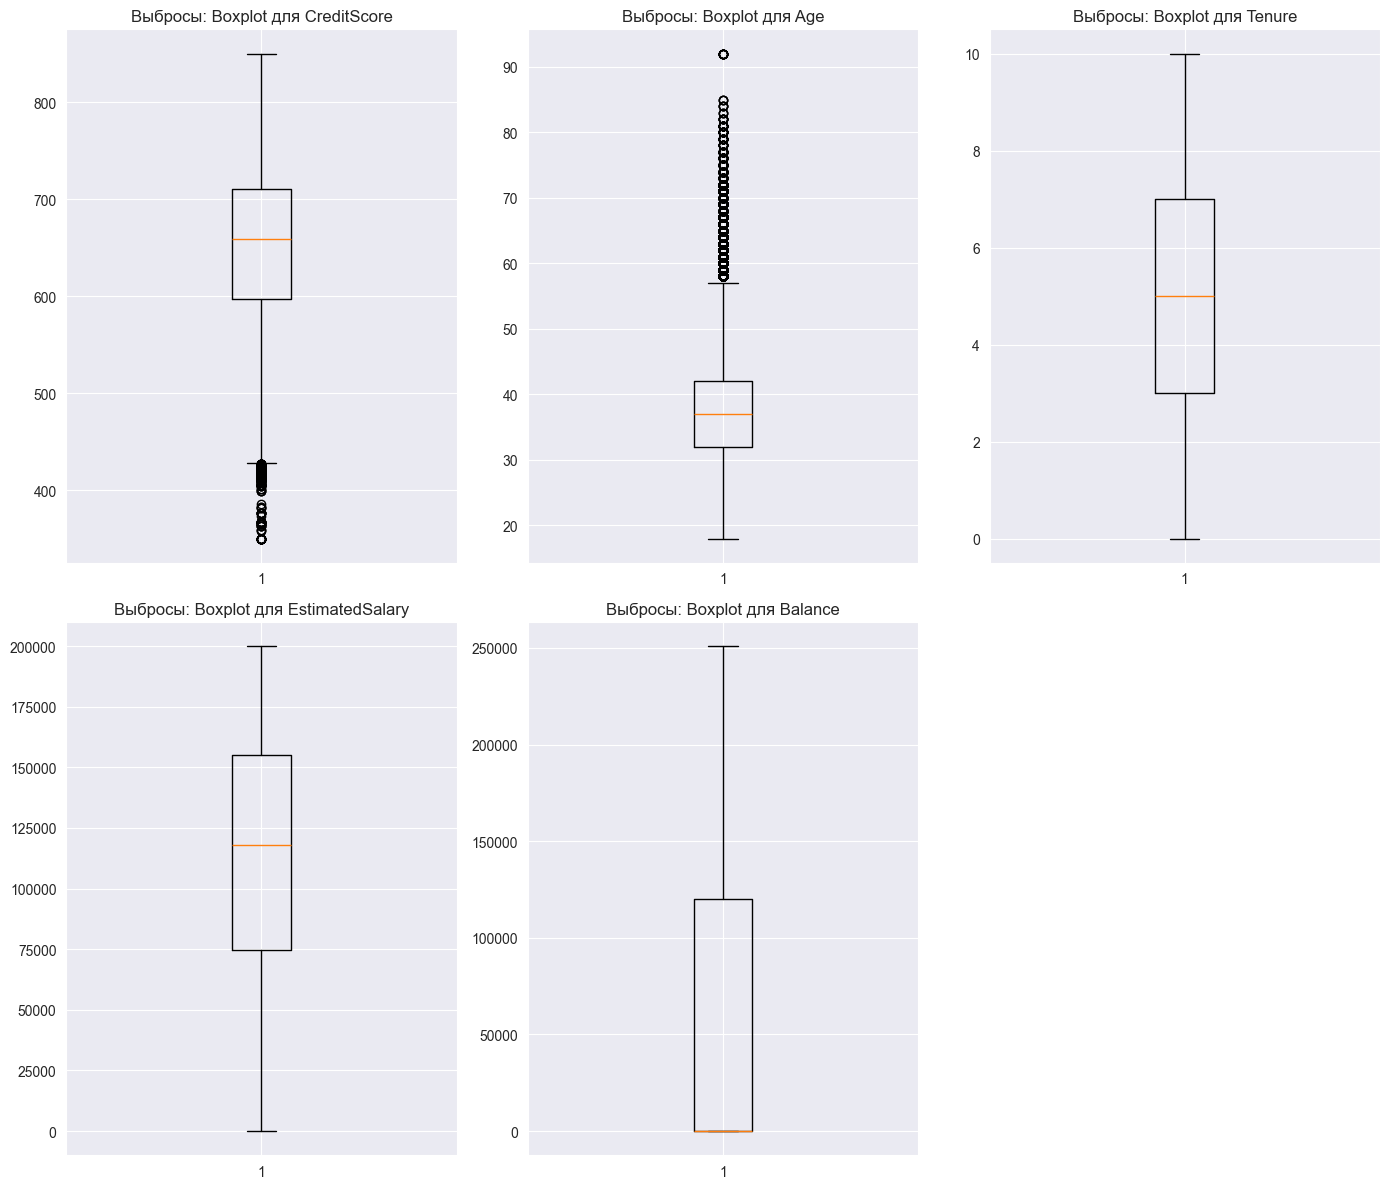

In [19]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Balance']
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(14, 12)) 
ax = ax.ravel()

for i, column in enumerate(num_cols): 
    ax[i].boxplot(X[column])
    ax[i].set_title(f'Выбросы: Boxplot для {column}')

ax[5].axis('off') # Скрываем пустой шестой график
plt.tight_layout()    
plt.show()


#### Распределение числовых признаков и их влияние на таргет

Exited
0    657.590710
1    652.220469
Name: CreditScore, dtype: float64


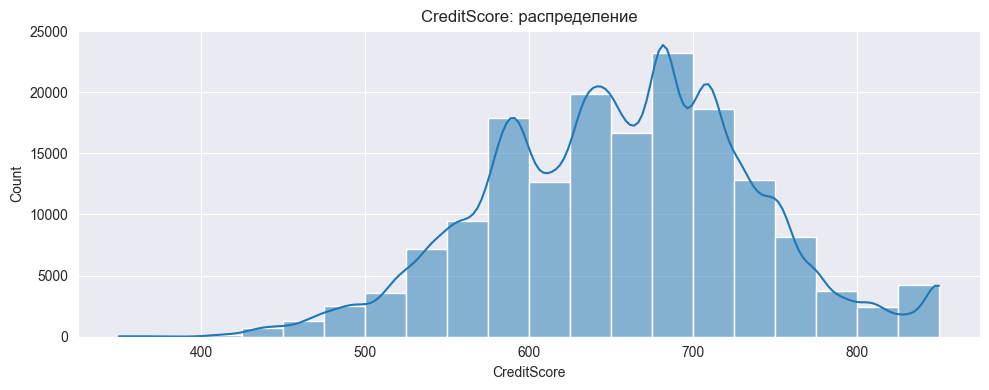

Exited
0    36.560474
1    43.958478
Name: Age, dtype: float64


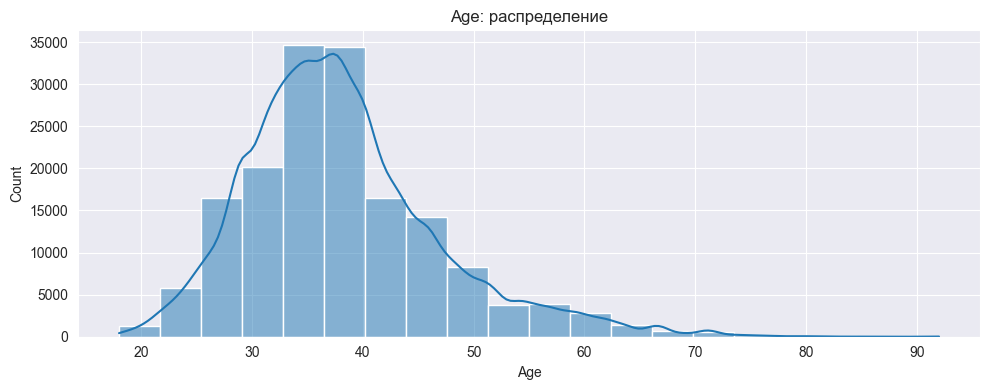

Exited
0    5.048796
1    4.914378
Name: Tenure, dtype: float64


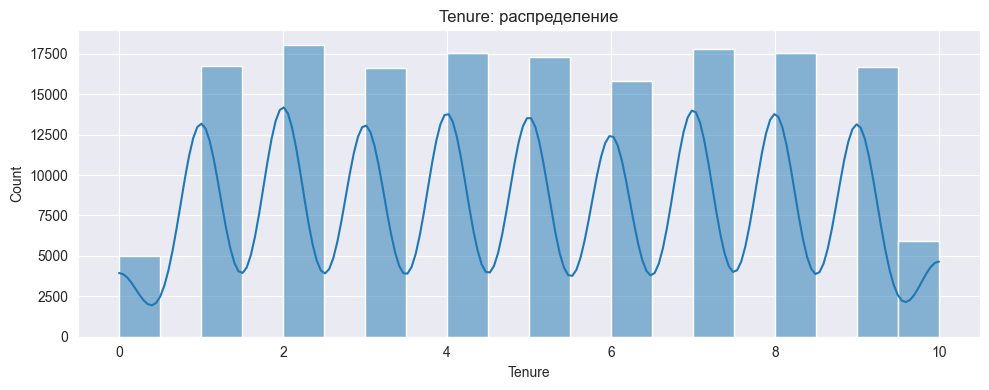

Exited
0    112084.293725
1    114402.496656
Name: EstimatedSalary, dtype: float64


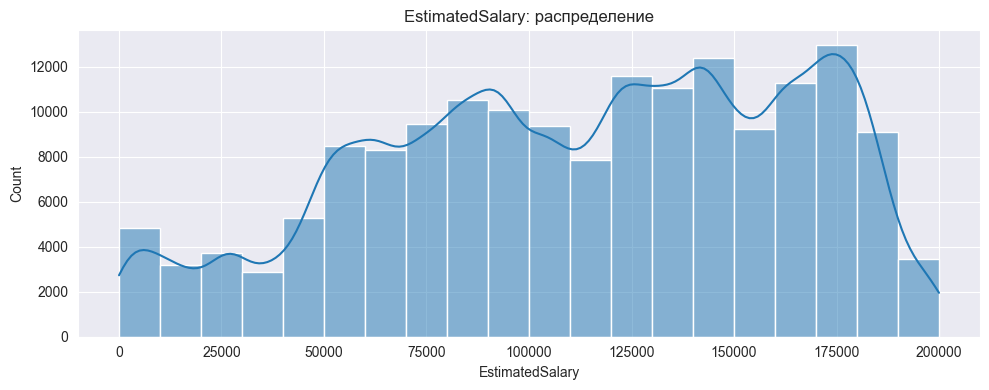

Exited
0    51255.807752
1    71209.978085
Name: Balance, dtype: float64


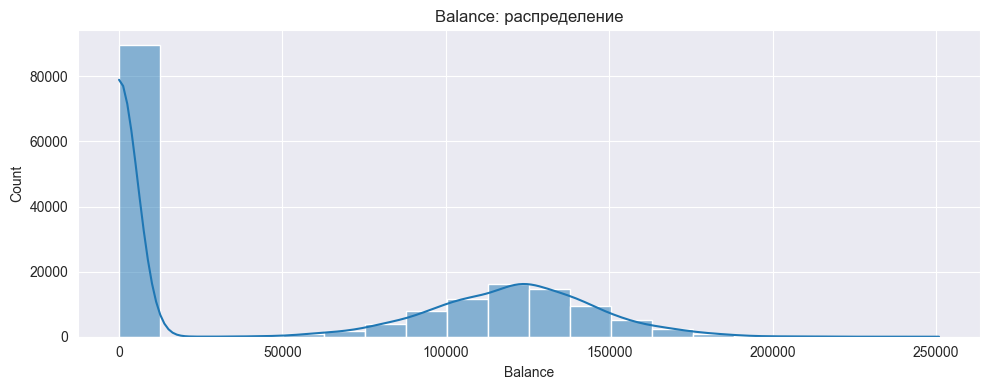

In [20]:
for feature in num_cols:
    # Проверка: отличается ли средний показатель у ушедших/оставшихся?
    print(df.groupby('Exited')[feature].mean())
    
    plt.figure(figsize=(10, 4))
    sns.histplot(X[feature], bins=20, kde=True)
    plt.title(f'{feature}: распределение')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show() 

#### Выводы по числовым признакам:
- `CreditScore`, `Age` : гистограммы распределения показали левый и правый хвосты соответственно. Предположим естественные причины наличия таких отклонений: низкий кредитный рейтинг и пожилой возраст клиентов. Это не выбросы. Для линейной модели применим масштабирование
- `Balance` медиана на боксплоте смещена влево, 54.3% нулевых значений (Profile Report). Это особенность данных, возможно на этапе отбора признаков добавить флаг `HasBalance`
- `EstimatedSalary` выбросов нет, есть скошенность влево
- `Tenure` (срок измеряется в годах) распределен почти равномерно

Влияние на класс таргета: 
- `Age` видим чёткую и понятную закономерность Разница: ~7.4 года - клиенты, которые уходят, в среднем старше
- `Balance` разница: ~20 000 — клиенты, которые уходят, имеют значительно больший средний баланс
 - `CreditScore`, `Tenure`, `EstimatedSalary` - разница есть, но она небольшая